# Offshore in the Gray Zone: Georgian Oligarchs and Offshore Finance
### QSS 20 Final Project — Naniko Kakonashvili

**Research question:** Do post-Soviet offshore actors share a distinct secrecy strategy, or do their patterns diverge by geopolitical alignment, EU integration, and domestic political development?

**Data:** ICIJ Offshore Leaks Database (Panama Papers, Pandora Papers, Paradise Papers, Bahamas Leaks, Offshore Leaks)

**Notebook contents:**
1. Setup & data loading
2. Data inventory & schema
3. Helper functions
4. Feature vector construction
5. Visualization 1 — Jurisdiction profile (grouped bar)
6. Visualization 2 — Georgian timeline (stacked bar)
7. Visualization 3 — Similarity network
8. Visualization 4 — Radar chart (offshore fingerprints)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from pathlib import Path
from scipy.stats import entropy as scipy_entropy
from scipy.spatial.distance import cosine

# ── Path configuration ────────────────────────────────────────────────────
RAW = Path("/Users/nanikokakonashvili/Desktop/offshore_leaks_project/data/raw/full-oldb.LATEST")

# Confirm files are present
csv_files = list(RAW.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(" ", f.name)

Found 6 CSV files:
  nodes-entities.csv
  nodes-officers.csv
  nodes-addresses.csv
  nodes-intermediaries.csv
  relationships.csv
  nodes-others.csv


In [3]:
# ── Load the four files used in analysis ─────────────────────────────────
officers       = pd.read_csv(RAW / "nodes-officers.csv",       low_memory=False)
entities       = pd.read_csv(RAW / "nodes-entities.csv",       low_memory=False)
relationships  = pd.read_csv(RAW / "relationships.csv",        low_memory=False)
intermediaries = pd.read_csv(RAW / "nodes-intermediaries.csv", low_memory=False)

print("Loaded:")
print(f"  Officers:       {len(officers):>8,}")
print(f"  Entities:       {len(entities):>8,}")
print(f"  Relationships:  {len(relationships):>8,}")
print(f"  Intermediaries: {len(intermediaries):>8,}")

Loaded:
  Officers:        771,315
  Entities:        814,344
  Relationships:  3,339,267
  Intermediaries:   25,629


## 2. Data Inventory & Schema

Quick inspection of columns and sample rows for each file.

In [4]:
# ── Officers schema ───────────────────────────────────────────────────────
# Key fields: node_id, name, country_codes (filter field), sourceID
print("OFFICERS columns:", officers.columns.tolist())
officers.head(3)

OFFICERS columns: ['node_id', 'name', 'countries', 'country_codes', 'sourceID', 'valid_until', 'note']


,node_id,name,countries,country_codes,sourceID,valid_until,note
0,12000001,KIM SOO IN,South Korea,KOR,Panama Papers,The Panama Papers data is current through 2015,NaN
1,12000002,Tian Yuan,China,CHN,Panama Papers,The Panama Papers data is current through 2015,NaN
2,12000003,GREGORY JOHN SOLOMON,Australia,AUS,Panama Papers,The Panama Papers data is current through 2015,NaN


In [5]:
# ── Entities schema ───────────────────────────────────────────────────────
# Key fields: node_id, jurisdiction_description (main analytical var), incorporation_date
print("ENTITIES columns:", entities.columns.tolist())
entities.head(3)

ENTITIES columns: ['node_id', 'name', 'original_name', 'former_name', 'jurisdiction', 'jurisdiction_description', 'company_type', 'address', 'internal_id', 'incorporation_date', 'inactivation_date', 'struck_off_date', 'dorm_date', 'status', 'service_provider', 'ibcRUC', 'country_codes', 'countries', 'sourceID', 'valid_until', 'note']


,node_id,name,original_name,former_name,jurisdiction,jurisdiction_description,company_type,address,internal_id,incorporation_date,...,struck_off_date,dorm_date,status,service_provider,ibcRUC,country_codes,countries,sourceID,valid_until,note
0,10000001,"TIANSHENG INDUSTRY AND TRADING CO., LTD.","TIANSHENG INDUSTRY AND TRADING CO., LTD.",NaN,SAM,Samoa,NaN,ORION HOUSE SERVICES (HK) LIMITED ROOM 1401; 1...,1001256.0,23-MAR-2006,...,15-FEB-2013,NaN,Defaulted,Mossack Fonseca,25221,HKG,Hong Kong,Panama Papers,The Panama Papers data is current through 2015,NaN
1,10000002,"NINGBO SUNRISE ENTERPRISES UNITED CO., LTD.","NINGBO SUNRISE ENTERPRISES UNITED CO., LTD.",NaN,SAM,Samoa,NaN,ORION HOUSE SERVICES (HK) LIMITED ROOM 1401; 1...,1001263.0,27-MAR-2006,...,15-FEB-2014,NaN,Defaulted,Mossack Fonseca,25249,HKG,Hong Kong,Panama Papers,The Panama Papers data is current through 2015,NaN
2,10000003,"HOTFOCUS CO., LTD.","HOTFOCUS CO., LTD.",NaN,SAM,Samoa,NaN,ORION HOUSE SERVICES (HK) LIMITED ROOM 1401; 1...,1000896.0,10-JAN-2006,...,15-FEB-2012,NaN,Defaulted,Mossack Fonseca,24138,HKG,Hong Kong,Panama Papers,The Panama Papers data is current through 2015,NaN


In [6]:
# ── Relationships schema ──────────────────────────────────────────────────
# Key field: rel_type — we use officer_of and intermediary_of
print("RELATIONSHIPS columns:", relationships.columns.tolist())
print("\nRelationship type breakdown:")
print(relationships["rel_type"].value_counts())

RELATIONSHIPS columns: ['node_id_start', 'node_id_end', 'rel_type', 'link', 'status', 'start_date', 'end_date', 'sourceID']

Relationship type breakdown:
rel_type
officer_of                  1720357
registered_address           832721
intermediary_of              598546
same_name_as                 104170
similar                       46761
same_company_as               15523
connected_to                  12145
same_as                        4272
same_id_as                     3120
underlying                     1308
similar_company_as              203
probably_same_officer_as        132
same_address_as                   5
same_intermediary_as              4
Name: count, dtype: int64


In [7]:
# ── Georgian officers — quick audit ──────────────────────────────────────
geo_officers = officers[officers["country_codes"].str.contains("GEO", na=False)]
print(f"Georgian officers in database: {len(geo_officers)}")
print(f"\nSource breakdown (which leak):")
print(geo_officers["sourceID"].value_counts())

Georgian officers in database: 281

Source breakdown (which leak):
sourceID
Pandora Papers - Alemán, Cordero, Galindo & Lee (Alcogal)    90
Panama Papers                                                74
Paradise Papers - Malta corporate registry                   63
Pandora Papers - Alpha Consulting                            19
Pandora Papers - Trident Trust                                9
Offshore Leaks                                                8
Pandora Papers - Fidelity Corporate Services                  6
Pandora Papers - SFM Corporate Services                       6
Paradise Papers - Appleby                                     5
Pandora Papers - CILTrust International                       1
Name: count, dtype: int64


## 3. Constants & Helper Functions

Defined once here, used by all visualizations below.

In [9]:
# ── Country groups ────────────────────────────────────────────────────────
COUNTRIES = {
    "GEO": "Georgia",  # focal post-Soviet case
    "LVA": "Latvia",   # post-Soviet, EU member since 2004
    "BLR": "Belarus",  # post-Soviet, no EU integration
    "RUS": "Russia",   # post-Soviet anchor
    "DEU": "Germany",  # EU anchor
    "FRA": "France",   # EU anchor
}

GROUPS = {
    "Georgia": "Post-Soviet (focal)",
    "Latvia":  "Post-Soviet (focal)",
    "Belarus": "Post-Soviet (focal)",
    "Russia":  "Post-Soviet (anchor)",
    "Germany": "EU (anchor)",
    "France":  "EU (anchor)",
}

# Jurisdictions classified by opacity level
# Blacklist: FATF/OECD/EU blacklisted — maximum secrecy
BLACKLIST = {
    "British Virgin Islands", "Panama", "Seychelles",
    "Bahamas", "Samoa", "Cook Islands", "Belize", "Niue"
}

# EU-adjacent: semi-transparent, tax-efficient but nominally regulated
EU_ADJACENT = {
    "Malta", "Bermuda", "Isle of Man", "Cayman Islands", "Mauritius"
}

# Colors per country (used consistently across all visualizations)
COLORS = {
    "Georgia": "#c9a84c",
    "Latvia":  "#e8b84b",
    "Belarus": "#d4a017",
    "Russia":  "#c0392b",
    "Germany": "#3498db",
    "France":  "#1a6fa8",
}

In [10]:
# ── Helper functions ──────────────────────────────────────────────────────

def get_country_data(code):
    """
    For a given ISO-3 country code, returns:
      ents       — DataFrame of offshore entities linked to that country's officers
      inter_ids  — list of intermediary node_ids serving those entities
    Uses only officer_of and intermediary_of relationship types.
    """
    off      = officers[officers["country_codes"].str.contains(code, na=False)]
    off_ids  = set(off["node_id"])

    ent_rels = relationships[
        (relationships["node_id_start"].isin(off_ids)) &
        (relationships["rel_type"] == "officer_of")
    ]
    ent_ids  = set(ent_rels["node_id_end"])
    ents     = entities[entities["node_id"].isin(ent_ids)].copy()

    int_rels = relationships[
        (relationships["node_id_end"].isin(ent_ids)) &
        (relationships["rel_type"] == "intermediary_of")
    ]
    return ents, int_rels["node_id_start"].tolist()


def shannon_entropy(series):
    """
    Shannon entropy (base 2) of a categorical series.
    High = spread evenly across many categories.
    Low  = concentrated in one or few categories.
    """
    counts = series.value_counts()
    probs  = counts / counts.sum()
    return float(scipy_entropy(probs, base=2))


def herfindahl(id_list):
    """
    Herfindahl-Hirschman Index of intermediary concentration.
    1.0 = one intermediary handles everything (monopoly).
    Low = spread across many wealth managers.
    """
    if not id_list:
        return 0.0
    s      = pd.Series(id_list)
    shares = s.value_counts() / len(s)
    return float((shares ** 2).sum())


print("Constants and helper functions defined.")

Constants and helper functions defined.


## 4. Feature Vector Construction

Each country is represented as a vector of 5 normalized features:

| Feature | What it measures |
|---|---|
| `blacklist_pct` | Share of entities in blacklisted jurisdictions |
| `juris_entropy` | Shannon entropy of jurisdiction distribution (diversity) |
| `inter_hhi` | Herfindahl index of intermediary concentration |
| `eu_adjacent_pct` | Share of entities in EU-adjacent jurisdictions (Malta etc.) |
| `temporal_norm` | Mean incorporation year, normalized 0–1 (recency) |

In [11]:
# ── Compute raw feature values per country ────────────────────────────────
all_years = pd.to_datetime(
    entities["incorporation_date"], format="mixed", errors="coerce"
).dt.year.dropna()
year_min, year_max = all_years.min(), all_years.max()

records = []
for code, name in COUNTRIES.items():
    ents, inter_ids = get_country_data(code)

    bl_pct    = (ents["jurisdiction_description"].isin(BLACKLIST).sum()
                 / len(ents)) if len(ents) > 0 else 0.0
    j_ent     = shannon_entropy(ents["jurisdiction_description"]) if len(ents) > 0 else 0.0
    hhi       = herfindahl(inter_ids)
    eu_pct    = (ents["jurisdiction_description"].isin(EU_ADJACENT).sum()
                 / len(ents)) if len(ents) > 0 else 0.0
    inc_years = pd.to_datetime(
        ents["incorporation_date"], format="mixed", errors="coerce"
    ).dt.year.dropna()
    mean_year = inc_years.mean() if len(inc_years) > 0 else year_min
    year_norm = (mean_year - year_min) / (year_max - year_min)

    records.append({
        "country":         name,
        "n_entities":      len(ents),
        "blacklist_pct":   round(bl_pct,        4),
        "juris_entropy":   round(j_ent,          4),
        "inter_hhi":       round(hhi,            4),
        "eu_adjacent_pct": round(eu_pct,         4),
        "temporal_norm":   round(float(year_norm),4),
    })

features_df = pd.DataFrame(records).set_index("country")
FEATURE_COLS = ["blacklist_pct", "juris_entropy", "inter_hhi",
                "eu_adjacent_pct", "temporal_norm"]

print("Raw feature vectors:")
features_df

Raw feature vectors:


,n_entities,blacklist_pct,juris_entropy,inter_hhi,eu_adjacent_pct,temporal_norm
country,,,,,,
Georgia,223,0.5516,1.9720,0.0680,0.2870,0.4937
Latvia,522,0.3084,1.7532,0.0486,0.5000,0.4919
Belarus,245,0.5143,1.8074,0.0417,0.1184,0.4886
Russia,11328,0.6003,1.9303,0.0238,0.1337,0.4853
Germany,8254,0.2858,1.7910,0.0437,0.6756,0.4870
France,4749,0.3367,2.3712,0.0084,0.5799,0.4855


In [12]:
# ── Normalize each feature to 0-1 across countries ───────────────────────
# Required for cosine similarity so no single feature dominates
norm_df = features_df[FEATURE_COLS].copy()
for col in FEATURE_COLS:
    col_min, col_max = norm_df[col].min(), norm_df[col].max()
    if col_max > col_min:
        norm_df[col] = (norm_df[col] - col_min) / (col_max - col_min)
    else:
        norm_df[col] = 0.0

print("Normalized feature vectors:")
norm_df.round(3)

Normalized feature vectors:


,blacklist_pct,juris_entropy,inter_hhi,eu_adjacent_pct,temporal_norm
country,,,,,
Georgia,0.845,0.354,1.000,0.303,1.000
Latvia,0.072,0.000,0.674,0.685,0.786
Belarus,0.727,0.088,0.559,0.000,0.393
Russia,1.000,0.287,0.258,0.027,0.000
Germany,0.000,0.061,0.592,1.000,0.202
France,0.162,1.000,0.000,0.828,0.024


In [13]:
# ── Cosine similarity — Georgia vs all others ─────────────────────────────
# Cosine similarity measures the angle between two vectors (0-1).
# 1.0 = identical offshore strategy profile.
# Abstracts away from scale differences (Russia has 11k entities, Georgia 223).
geo_vec = norm_df.loc["Georgia"].values

similarity = {}
for country in norm_df.index:
    if country == "Georgia":
        continue
    vec = norm_df.loc[country].values
    if np.linalg.norm(vec) == 0 or np.linalg.norm(geo_vec) == 0:
        similarity[country] = 0.0
    else:
        similarity[country] = round(1 - cosine(geo_vec, vec), 4)

sim_df = (pd.DataFrame.from_dict(similarity, orient="index", columns=["similarity_to_georgia"])
          .sort_values("similarity_to_georgia", ascending=False))
sim_df["group"] = sim_df.index.map(GROUPS)

print("Cosine similarity to Georgia:")
print(sim_df.to_string())

ru_sim = float(sim_df.loc["Russia", "similarity_to_georgia"])
eu_avg = float(sim_df.loc[["Germany", "France"], "similarity_to_georgia"].mean())
print(f"\nGeorgia–Russia similarity: {ru_sim:.3f}")
print(f"Georgia–EU avg similarity: {eu_avg:.3f}")
print(f">> Georgia is structurally closer to {'Russia' if ru_sim > eu_avg else 'the EU'}.")

Cosine similarity to Georgia:
         similarity_to_georgia                 group
Belarus                 0.9316   Post-Soviet (focal)
Latvia                  0.8117   Post-Soviet (focal)
Russia                  0.6609  Post-Soviet (anchor)
Germany                 0.5532           EU (anchor)
France                  0.3415           EU (anchor)

Georgia–Russia similarity: 0.661
Georgia–EU avg similarity: 0.447
>> Georgia is structurally closer to Russia.


## 5. Visualization 1 — Jurisdiction Profile

Grouped bar chart comparing offshore jurisdiction preferences across Georgia, Russia, Germany, and France.

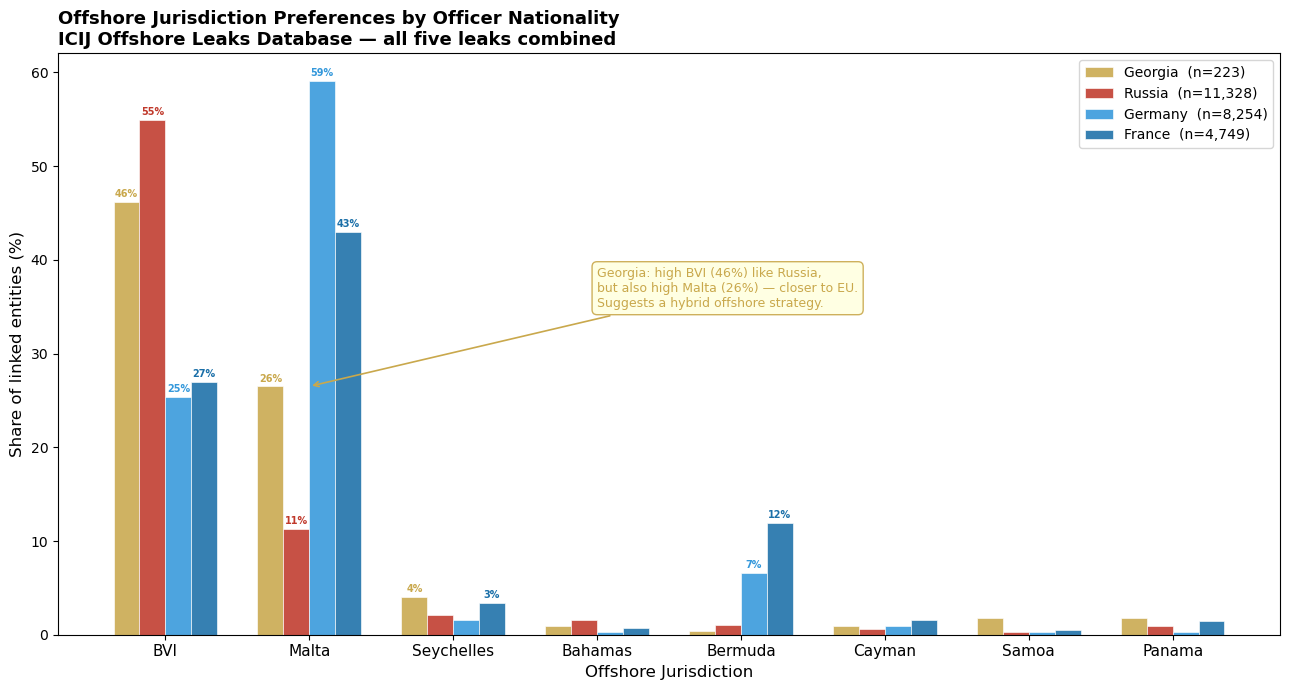

Viz 1 saved.


In [14]:
top_juris    = ["British Virgin Islands", "Malta", "Seychelles",
                "Bahamas", "Bermuda", "Cayman Islands", "Samoa", "Panama"]
short_labels = ["BVI", "Malta", "Seychelles", "Bahamas",
                "Bermuda", "Cayman", "Samoa", "Panama"]

compare_countries = {"GEO": "Georgia", "RUS": "Russia",
                     "DEU": "Germany", "FRA": "France"}
compare_colors    = [COLORS[name] for name in compare_countries.values()]

pct_data = {}
totals   = {}
for code, name in compare_countries.items():
    ents, _ = get_country_data(code)
    total   = len(ents)
    totals[name]   = total
    pct_data[name] = {j: round((ents["jurisdiction_description"] == j).sum()
                                / total * 100, 1) if total > 0 else 0
                      for j in top_juris}

x      = np.arange(len(top_juris))
width  = 0.18
n      = len(compare_countries)

plt.figure(figsize=(13, 7))
for i, (code, name) in enumerate(compare_countries.items()):
    offset = (i - (n - 1) / 2) * width
    vals   = [pct_data[name][j] for j in top_juris]
    plt.bar(x + offset, vals, width,
            label=f"{name}  (n={totals[name]:,})",
            color=compare_colors[i], alpha=0.88,
            edgecolor="white", linewidth=0.5)
    for xi, val in zip(x + offset, vals):
        if val >= 2.5:
            plt.text(xi, val + 0.3, f"{val:.0f}%",
                     ha="center", va="bottom",
                     fontsize=7, color=compare_colors[i], fontweight="bold")

plt.xticks(x, short_labels, fontsize=11)
plt.xlabel("Offshore Jurisdiction", fontsize=12)
plt.ylabel("Share of linked entities (%)", fontsize=12)
plt.title("Offshore Jurisdiction Preferences by Officer Nationality\n"
          "ICIJ Offshore Leaks Database — all five leaks combined",
          fontsize=13, fontweight="bold", loc="left")
plt.legend(fontsize=10)
plt.annotate(
    "Georgia: high BVI (46%) like Russia,\n"
    "but also high Malta (26%) — closer to EU.\n"
    "Suggests a hybrid offshore strategy.",
    xy=(1, pct_data["Georgia"]["Malta"]),
    xytext=(3.0, 35), fontsize=9, color=COLORS["Georgia"],
    arrowprops=dict(arrowstyle="->", color=COLORS["Georgia"], lw=1.2),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
              edgecolor=COLORS["Georgia"], alpha=0.9)
)
plt.tight_layout()
plt.savefig(RAW.parents[2] / "viz1_jurisdiction_profile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Viz 1 saved.")

## 6. Visualization 2 — Georgian Entity Timeline

Stacked bar chart of new Georgian-linked offshore entities by year, colored by jurisdiction type.

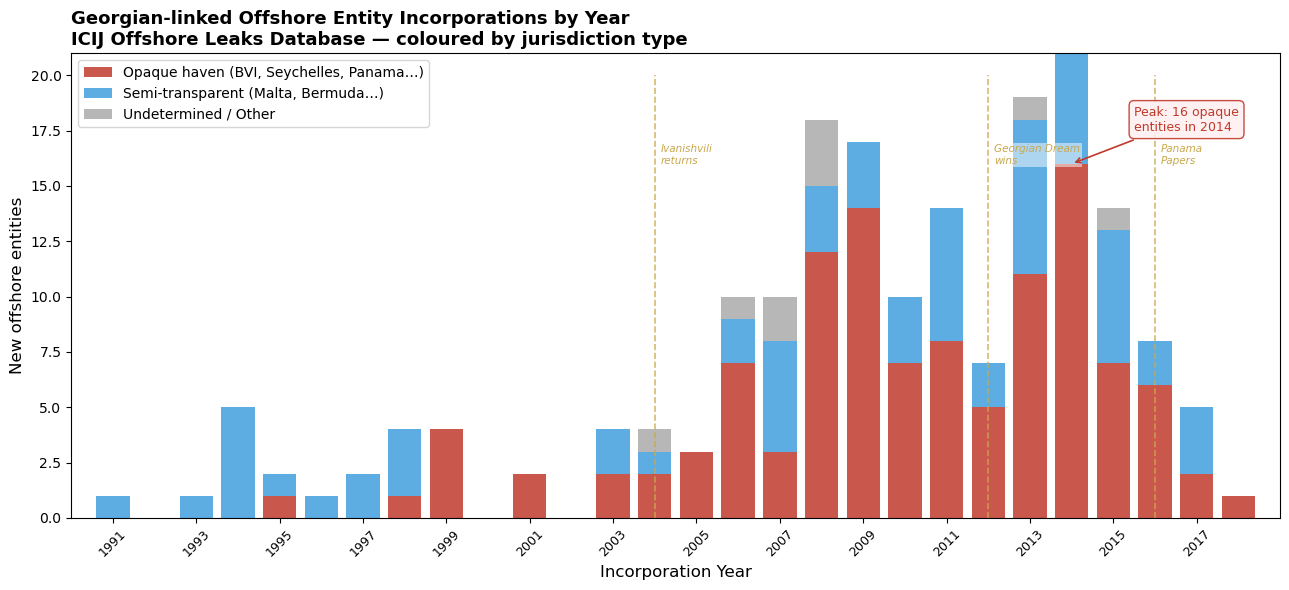

Viz 2 saved. Note: 36 entities excluded (no incorporation date).


In [15]:
geo_ents, _ = get_country_data("GEO")
geo_ents["inc_year"] = pd.to_datetime(
    geo_ents["incorporation_date"], format="mixed", errors="coerce"
).dt.year

def classify_jurisdiction(j):
    if j in BLACKLIST:    return "Opaque haven"
    if j in EU_ADJACENT:  return "Semi-transparent"
    return "Undetermined"

geo_ents["juris_type"] = geo_ents["jurisdiction_description"].apply(classify_jurisdiction)

timeline = (geo_ents[geo_ents["inc_year"].between(1991, 2018)]
            .groupby(["inc_year", "juris_type"]).size()
            .unstack(fill_value=0)
            .reindex(range(1991, 2019), fill_value=0))
for col in ["Opaque haven", "Semi-transparent", "Undetermined"]:
    if col not in timeline.columns:
        timeline[col] = 0

years = timeline.index.astype(int)
plt.figure(figsize=(13, 6))
plt.bar(years, timeline["Opaque haven"],
        color="#c0392b", alpha=0.85, label="Opaque haven (BVI, Seychelles, Panama…)")
plt.bar(years, timeline["Semi-transparent"],
        bottom=timeline["Opaque haven"],
        color="#3498db", alpha=0.80, label="Semi-transparent (Malta, Bermuda…)")
plt.bar(years, timeline["Undetermined"],
        bottom=timeline["Opaque haven"] + timeline["Semi-transparent"],
        color="#888888", alpha=0.60, label="Undetermined / Other")

events = {2004: "Ivanishvili\nreturns", 2012: "Georgian Dream\nwins", 2016: "Panama\nPapers"}
for yr, label in events.items():
    plt.vlines(yr, 0, 20, colors="#c9a84c", linewidth=1.2, linestyle="--", alpha=0.8)
    plt.annotate(label, xy=(yr + 0.15, 16), fontsize=7.5,
                 color="#c9a84c", style="italic",
                 bbox=dict(facecolor="white", edgecolor="none", alpha=0.5, pad=1))

peak_yr  = int(timeline["Opaque haven"].idxmax())
peak_val = int(timeline.loc[peak_yr, "Opaque haven"])
plt.annotate(f"Peak: {peak_val} opaque\nentities in {peak_yr}",
             xy=(peak_yr, peak_val), xytext=(peak_yr + 1.5, peak_val + 1.5),
             fontsize=9, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2),
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff0f0",
                       edgecolor="#c0392b", alpha=0.9))

plt.xlabel("Incorporation Year", fontsize=12)
plt.ylabel("New offshore entities", fontsize=12)
plt.xticks(years[::2], fontsize=9, rotation=45)
plt.xlim(1990, 2019)
plt.title("Georgian-linked Offshore Entity Incorporations by Year\n"
          "ICIJ Offshore Leaks Database — coloured by jurisdiction type",
          fontsize=13, fontweight="bold", loc="left")
plt.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig(RAW.parents[2] / "viz2_georgian_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Viz 2 saved. Note: {geo_ents['inc_year'].isna().sum()} entities excluded (no incorporation date).")

## 7. Visualization 3 — Similarity Network

Countries as nodes. Edges drawn where cosine similarity ≥ 0.70. Node size proportional to entity count.

In [16]:
# ── Build pairwise similarity matrix ─────────────────────────────────────
countries_list = list(norm_df.index)
sim_matrix = pd.DataFrame(index=countries_list, columns=countries_list, dtype=float)

for c1 in countries_list:
    for c2 in countries_list:
        v1, v2 = norm_df.loc[c1].values, norm_df.loc[c2].values
        if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0:
            sim_matrix.loc[c1, c2] = 0.0
        else:
            sim_matrix.loc[c1, c2] = round(1 - cosine(v1, v2), 4)

print("Pairwise similarity matrix:")
sim_matrix.round(3)

Pairwise similarity matrix:


,Georgia,Latvia,Belarus,Russia,Germany,France
Georgia,1.000,0.812,0.932,0.661,0.553,0.342
Latvia,0.812,1.000,0.593,0.199,0.846,0.367
Belarus,0.932,0.593,1.000,0.835,0.352,0.164
Russia,0.661,0.199,0.835,1.000,0.156,0.336
Germany,0.553,0.846,0.352,0.156,1.000,0.578
France,0.342,0.367,0.164,0.336,0.578,1.000


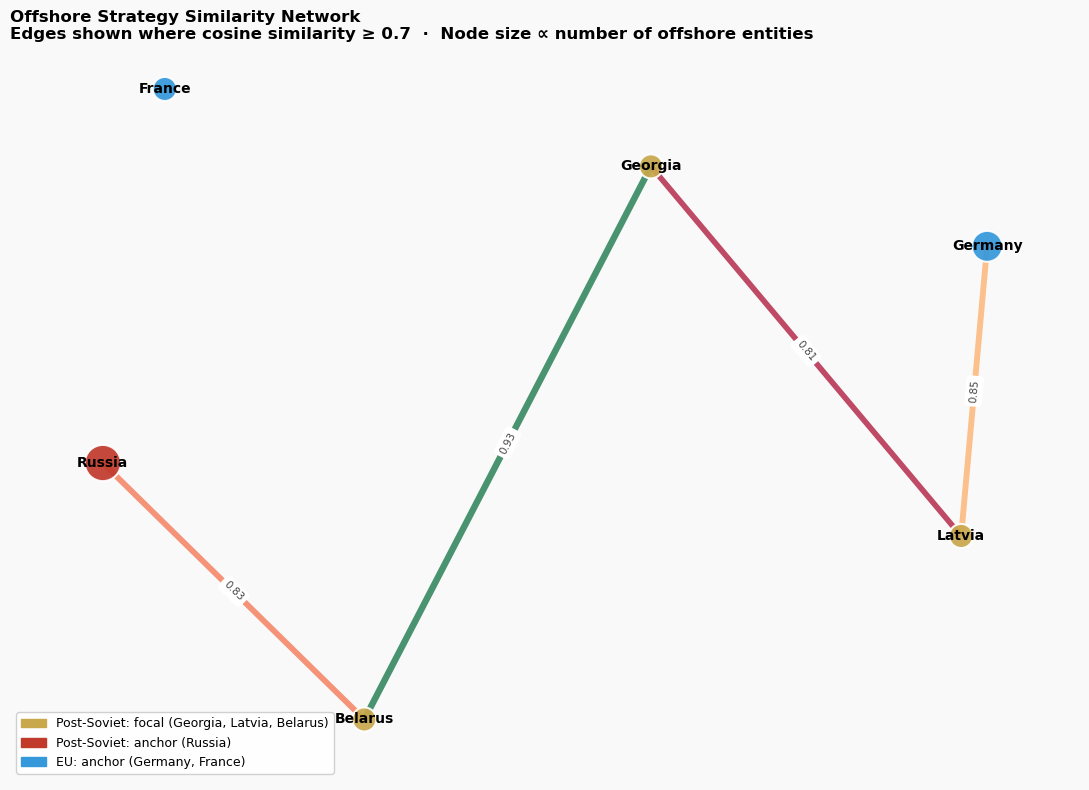

Viz 3 saved.


In [17]:
THRESHOLD = 0.70

G = nx.Graph()
for country in countries_list:
    G.add_node(country, group=GROUPS[country],
               n_entities=int(features_df.loc[country, "n_entities"]))
for i, c1 in enumerate(countries_list):
    for j, c2 in enumerate(countries_list):
        if j <= i:
            continue
        sim = float(sim_matrix.loc[c1, c2])
        if sim >= THRESHOLD:
            G.add_edge(c1, c2, weight=sim)

pos = nx.spring_layout(G, weight="weight", seed=42, k=2.5)

group_colors = {
    "Post-Soviet (focal)":   "#c9a84c",
    "Post-Soviet (anchor)": "#c0392b",
    "EU (anchor)":          "#3498db",
}
node_colors  = [group_colors[G.nodes[n]["group"]] for n in G.nodes]
node_sizes   = [max(300, G.nodes[n]["n_entities"] * 0.06) for n in G.nodes]
edge_weights = [G[u][v]["weight"] for u, v in G.edges]

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("#f9f9f9")
ax.set_facecolor("#f9f9f9")

nx.draw_networkx_edges(G, pos, ax=ax, width=[w * 5 for w in edge_weights],
                       edge_color=edge_weights, edge_cmap=plt.cm.RdYlGn, alpha=0.7)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, alpha=0.92,
                       linewidths=1.5, edgecolors="white")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")
nx.draw_networkx_edge_labels(
    G, pos, edge_labels={(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges},
    ax=ax, font_size=7.5, font_color="#444444"
)

legend_handles = [
    mpatches.Patch(color="#c9a84c", label="Post-Soviet: focal (Georgia, Latvia, Belarus)"),
    mpatches.Patch(color="#c0392b", label="Post-Soviet: anchor (Russia)"),
    mpatches.Patch(color="#3498db", label="EU: anchor (Germany, France)"),
]
ax.legend(handles=legend_handles, fontsize=9, loc="lower left", framealpha=0.9)
ax.set_title("Offshore Strategy Similarity Network\n"
             f"Edges shown where cosine similarity ≥ {THRESHOLD}  ·  "
             "Node size ∝ number of offshore entities",
             fontsize=12, fontweight="bold", loc="left", pad=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(RAW.parents[2] / "viz3_similarity_network.png", dpi=150, bbox_inches="tight")
plt.show()
print("Viz 3 saved.")

## 8. Visualization 4 — Radar Chart (Offshore Fingerprints)

Each country's normalized feature vector as a polygon. Overlapping polygons indicate similar offshore strategies.

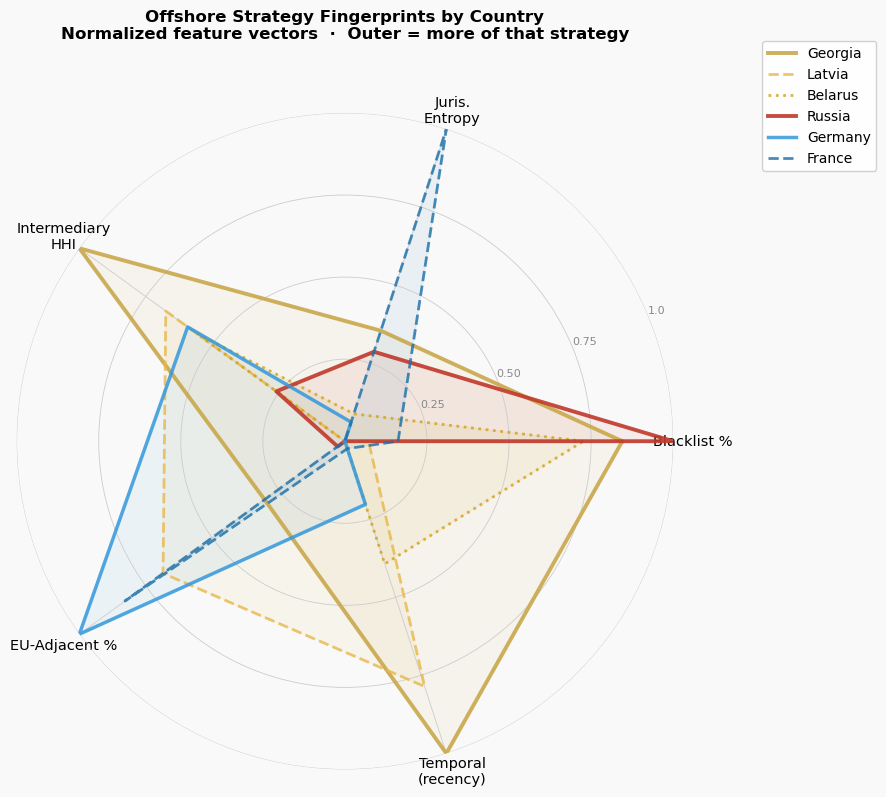

Viz 4 saved.


In [18]:
labels  = ["Blacklist %", "Juris.\nEntropy", "Intermediary\nHHI",
           "EU-Adjacent %", "Temporal\n(recency)"]
n_vars  = len(labels)
angles  = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("#f9f9f9")
ax.set_facecolor("#f9f9f9")

styles = {
    "Georgia": ("-",  2.8, 0.90),
    "Latvia":  ("--", 2.0, 0.80),
    "Belarus": (":",  2.0, 0.80),
    "Russia":  ("-",  2.8, 0.90),
    "Germany": ("-",  2.5, 0.85),
    "France":  ("--", 2.0, 0.80),
}

for country, (ls, lw, alpha) in styles.items():
    values  = norm_df.loc[country, FEATURE_COLS].tolist()
    values += values[:1]
    ax.plot(angles, values, color=COLORS[country],
            linestyle=ls, linewidth=lw, label=country, alpha=alpha)
    ax.fill(angles, values, color=COLORS[country], alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10.5, fontweight="500")
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], fontsize=8, color="#888888")
ax.set_ylim(0, 1)
ax.spines["polar"].set_visible(False)
ax.grid(color="#cccccc", linewidth=0.6)
ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.12), fontsize=10, framealpha=0.9)
ax.set_title("Offshore Strategy Fingerprints by Country\n"
             "Normalized feature vectors  ·  Outer = more of that strategy",
             fontsize=12, fontweight="bold", y=1.10)

plt.tight_layout()
plt.savefig(RAW.parents[2] / "viz4_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Viz 4 saved.")